## Exploratory Data Analysis for Climate Trends in Kenya


Importing dependencies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading and Date Parsing

**Loading the data and viewing the top rows of the data** 

In [2]:
df = pd.read_csv("kenya.csv")
print(df.shape)
print(df.head())
print(df.info())

(4108, 12)
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  19.56    28.99    12.09      16.90         0.00  45.32  3.12   
1  2015    2  19.63    29.77    11.04      18.73         0.00  38.76  3.23   
2  2015    3  20.40    30.57    11.71      18.86         0.00  41.75  3.46   
3  2015    4  21.33    31.20    13.02      18.18         3.49  51.87  2.29   
4  2015    5  20.41    29.52    12.38      17.14         1.79  48.04  1.77   

   WS2M_MAX     PS  QV2M  
0      4.76  83.68  6.88  
1      4.35  83.67  5.85  
2      4.68  83.69  6.65  
3      4.00  83.62  8.60  
4      4.05  83.54  7.64  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64

In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16
4107,2026,90,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40


**adding country column**

In [4]:
df["country"] = "Kenya"

**Converting YEAR and DOY columns in to datetime column**

In [5]:
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

**Extracting Month as a separate column**

In [6]:
df["Month"] = df["Date"].dt.month
df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


### 2. Summary Statistics & Missing-Value Report

**Replacing all occurrences of -999 with np.nan**

In [7]:
df.replace(-999, np.nan, inplace=True)

**Extracting and droping duplicated rows**

In [8]:
duplicates = df.duplicated().sum()
print(f"There are {duplicates} duplicate rows")

df = df.drop_duplicates()

There are 0 duplicate rows


**Checking duplicates for columns**

In [9]:
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(f"{col}: {dup_count} duplicate values")

YEAR: 4096 duplicate values
DOY: 3742 duplicate values
T2M: 3417 duplicate values
T2M_MAX: 3098 duplicate values
T2M_MIN: 3451 duplicate values
T2M_RANGE: 3015 duplicate values
PRECTOTCORR: 3413 duplicate values
RH2M: 1602 duplicate values
WS2M: 3700 duplicate values
WS2M_MAX: 3624 duplicate values
PS: 4028 duplicate values
QV2M: 3400 duplicate values
country: 4107 duplicate values
Date: 0 duplicate values
Month: 4096 duplicate values


**Statistical summary** 

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


**Interpretation of Statistical summary**
**(YEAR, DOY, Date)**

- DOY ranges from 1 to 366, confirming full yearly coverage including leap years.

- The median date is 2020-08-15, indicating balanced distribution across years.
  
**Tempearture varibales** 

- It range from 15.26°C to 25.4°C with average daily temperature(T2M) 20.43°C.

- Maximumtemperature(T2M_MAX) is 34.27°C but Minimum  temperature(T2M_MIN) drops to 8.97°C, showing noticeable seasonal variation.

- Daily temperature range(T2M_RANGE) has a mean of 13.17°C, with values between 4.11°C and 20.12°C, indicating moderate temperature differences.

**PRECTOTCORR/Precipitation** 

- The average daily rainfall is 1.47mm 
- The median value is 0.38 mm, which is much lower than the mean, shows a strong right-skewed distribution
- The maximum value is 51.65mm, confirming the presence of rare but intense rainfall events.

**Relative humidity/ RH2M** 

- The average humidity 65.85%, ranging from 28.42% to 91.07%.
- The median (62.22%) is very close to the mean, suggesting a fairly symmetric distribution.
- moderate to high humidity conditions, with occasional dry periods.
  
**Wind Speed (WS2M, WS2M_MAX)**

- Average wind speed (WS2M) is 3.06 m/s, ranging from 0.61 to 5.28 m/s.
- Maximum wind (WS2M_MAX) reach 7.49 m/s, indicating occasional strong wind events.
- Wind conditions are generally moderate and stable, with periodic spikes.

**Pressure (PS)**

- Atmospheric pressure is very stable with a mean of 83.72, ranging from 83.31 to 84.17.
- The very low standard deviation (0.13) indicates extremely consistent atmospheric conditions over time.

**Specific Humidity (QV2M)**

- The average specific humidity is 11.05, ranging from 4.78 to 15.04.
- moderate moisture content in the air, with noticeable variability across seasons.

 **Counting missing values, Computing percentage of missing valuees, Listing values with >5%**

In [11]:
count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Values" : count,
    "percentage (%)": missing_percent,
})

print(missing_report)
high_missing = missing_percent[missing_percent > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print(f"{high_missing} number of  columns found with >5% missing values.")

             Missing Values  percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


**Missing Value Analysis**

The dataset shows no missing values across all columns and since no column is greater than 5%, no data cleaning required for missing values. It shows higher data quality and  suitable for exploratory data analysis. 

### 3. Outlier Detection & Basic Cleaning

In [12]:
#Selected columns to check for outliers
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

#Calculate Z-scores for each value in the columns
z_scores = stats.zscore(df[cols])

#Flag rows where |Z| > 3
outliers = (np.abs(z_scores) > 3)

#count rows 
outlier_count = outliers.any(axis=1).sum()

print(f"{outlier_count} rows contain outliers")

121 rows contain outliers


**Outlier Analysis**

- *Found*: 121 outliers

- *Observation*: Outliers rows are 121 and 132/4108 ~ 3 % outliers exist

- *Desision*: It should be retain

- *Reasoning*: The extreme values are expected and represent real-world weather conditions.

 **Handling remaining missing values**

In [13]:
row_missing_percent = df.isna().mean(axis=1) * 100
row_missing_percent.head()

df = df[row_missing_percent <= 30]

#applying forward-fill for weather variables

weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df[weather_cols] = df[weather_cols].ffill()

#dropping rows 
df = df.dropna()

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


Rows with >30% missing data removed, variables forward-filled and remaining missing values were dropped


**Exporting cleaned dataset**

In [14]:
df.to_csv("data/kenya_clean.csv", index=False)

### 4.Time Series Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_11436\2321122583.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["T2M"].resample("M").mean()


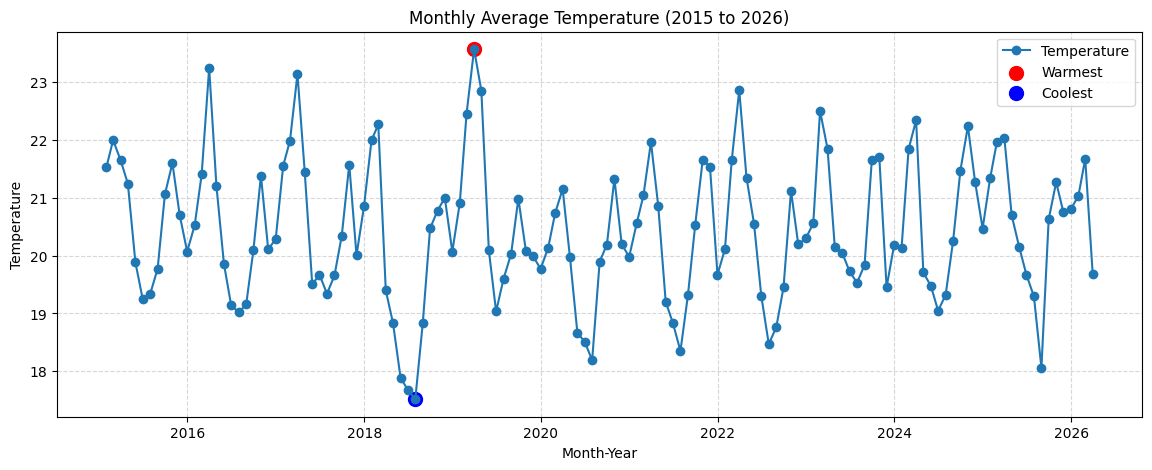

Warmest Month: 2019-03-31 00:00:00
Coolest Month: 2018-07-31 00:00:00


In [15]:
#Plotting monthly Average Temperature

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.set_index("Date", inplace=True)

# Calculate monthly average temperature
monthly_temp = df["T2M"].resample("M").mean()

# Plotting monthly average Temperature
plt.figure(figsize=(14,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o', label="Temperature")

# Find warmest and coolest months
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_value = monthly_temp.max()
coolest_value = monthly_temp.min()

# Highlight points
plt.scatter(warmest_month, warmest_value, color="red", s=100, label="Warmest")
plt.scatter(coolest_month, coolest_value, color="blue", s=100, label="Coolest") 

plt.title("Monthly Average Temperature (2015 to 2026)")
plt.xlabel("Month-Year")
plt.ylabel("Temperature")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

print("Warmest Month:", warmest_month)
print("Coolest Month:", coolest_month)


**Monthly Temperature Analysis**

Seasonality: it shows a clear repeating seasonal pattern, indicating consistent climate cycles over the years.

**Monthly total rainfall**

C:\Users\user\AppData\Local\Temp\ipykernel_11436\1343323091.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df["PRECTOTCORR"].resample("M").sum()


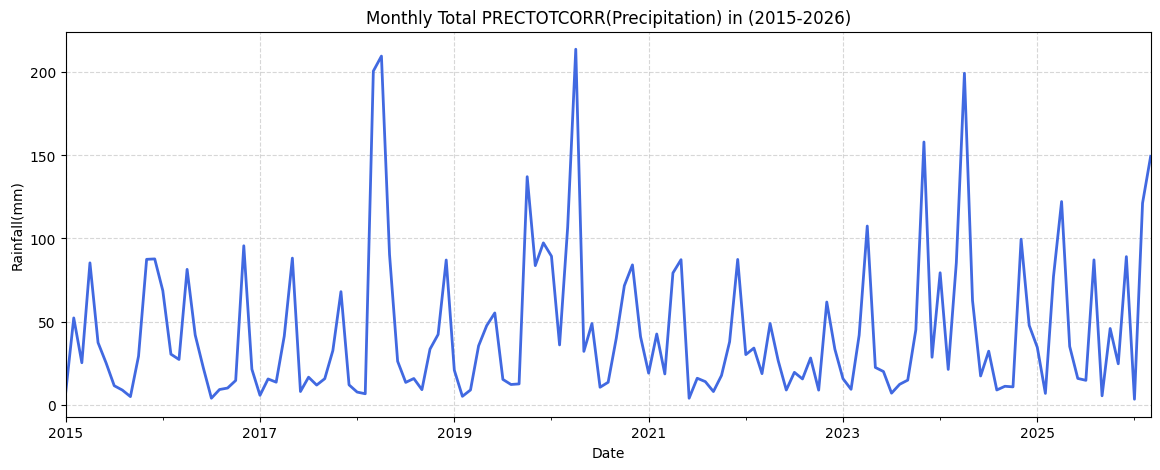

Rainy Months:
 Date
2020-04-30    213.89
2018-04-30    209.74
2018-03-31    200.73
Name: PRECTOTCORR, dtype: float64


In [23]:
#Plotting monthly Total Rainfall

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.set_index("Date", inplace=True)

monthly_rain = df["PRECTOTCORR"].resample("M").sum()

plt.figure(figsize=(14,5))

monthly_rain.plot(color='royalblue', linewidth=2)

plt.title("Monthly Total PRECTOTCORR(Precipitation) in (2015-2026)")
plt.xlabel("Date")
plt.ylabel("Rainfall(mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Identifying peak rainy months
top_rain = monthly_rain.sort_values(ascending=False).head(3)
print("Rainy Months:\n", top_rain)

### 5. Correlation and RelationShip Analysis

 Heatmap of correlations across all numeric columns


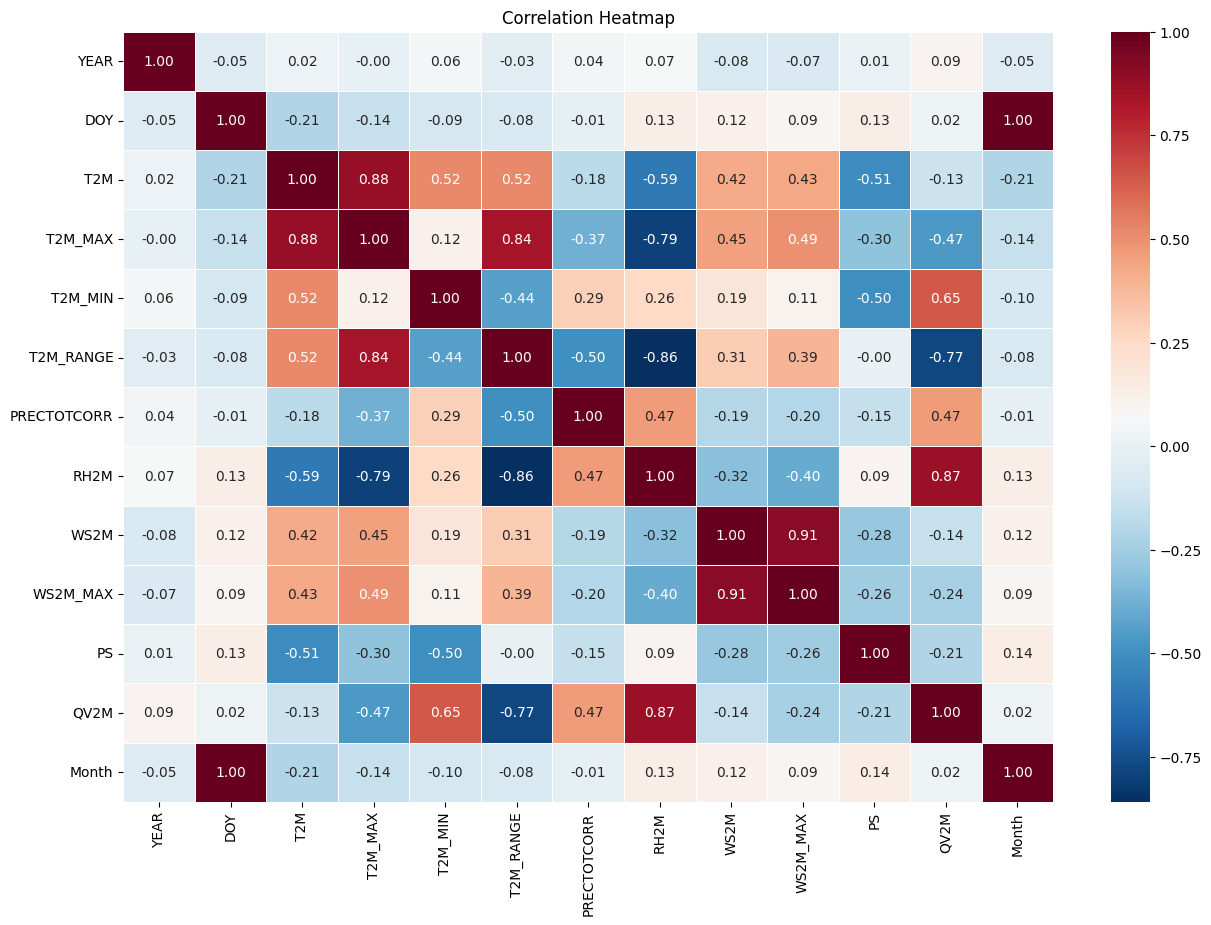

In [17]:
print(" Heatmap of correlations across all numeric columns")
#Select numeric columns
corr = df.select_dtypes(include="number").corr()

# Plotting a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, fmt='.2f',  cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Correlation & Relationship Analysis**

- The Darker colors signify strong correlation, while light colors represents weaker correlations.

- Temperature and Humidity have positive correlation and move in same directions. As Temperature increases, humidity also increases. 

- Negative correlation variables move in opposite directions. An increase in one variable is associated with a decrease in the other.

**Scatter Plot 1: T2M vs RH2M**

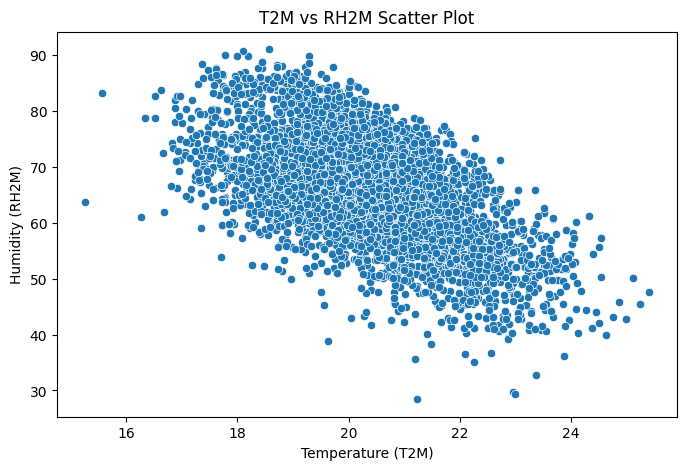

In [18]:
#Scatter plot between Temperature and Humidity
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M"], y=df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")

plt.title("T2M vs RH2M Scatter Plot")
plt.show()

**Scatter Plot 2: T2M_RANGE vs WS2M**

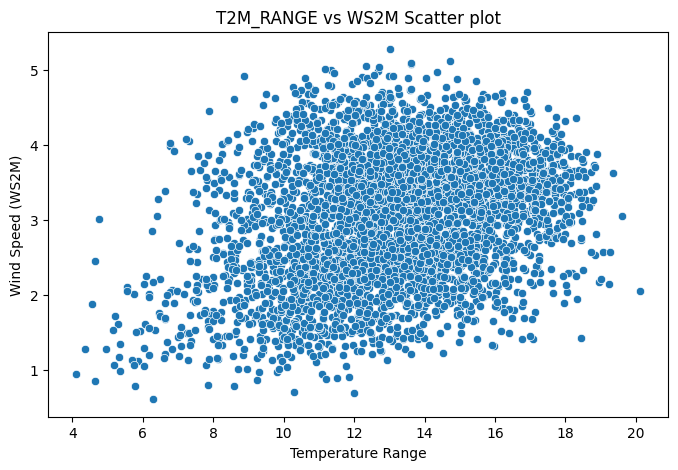

In [19]:
##Scatter plot between Temperature and Humidity

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])

plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.title("T2M_RANGE vs WS2M Scatter plot")
plt.show()

**The strongest correlations**

In [20]:
corr = df.select_dtypes(include="number").corr()

# Convert correlation matrix into pairs
corr_pairs = corr.unstack()

# Remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

#remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()

# Sort by strongest absolute correlation
strongest = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)


# Top 3 strongest correlations
print(strongest.head(3))

DOY   Month       0.996557
WS2M  WS2M_MAX    0.911457
T2M   T2M_MAX     0.880907
dtype: float64


**Strongest Correlations Analysis**

I. DOY vs Month — 0.9966 (Very Strong Positive Correlation)

- This extremely high correlation indicates that Day of Year (DOY) and Month are almost perfectly aligned.
- This is a redundant temporal relationship, not a physical climate interaction.

II. WS2M vs WS2M_MAX — 0.9115

- This shows that average wind speed and maximum wind speed increase together strongly.
- This reflects consistent wind behavior patterns, where calm and windy days scale together.

III. T2M vs T2M_MAX — 0.8809

- Warmer days tend to have higher peak temperatures, showing a stable thermal pattern. 


### 6. Distribution Analysis

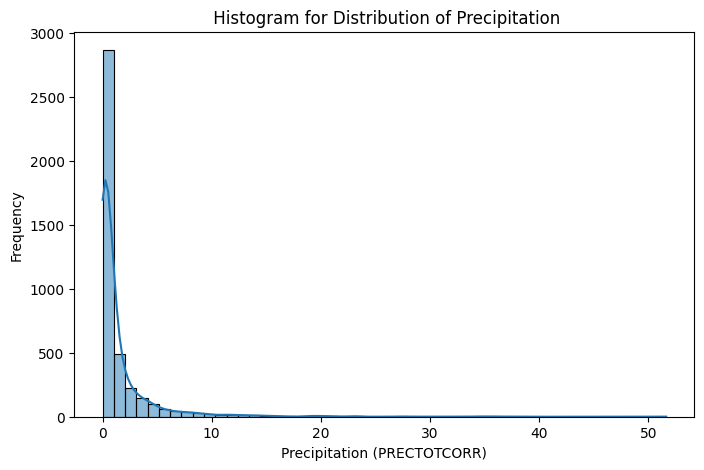

In [21]:
plt.figure(figsize=(8,5))

# Use log scale if data is highly skewed
sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)

plt.xlabel("Precipitation (PRECTOTCORR)")
plt.ylabel("Frequency")
plt.title(" Histogram for Distribution of Precipitation")

plt.show()

**Precipitation Distribution**

- The distribution is highly right-skewed (positively skewed), most values are concentrated near 0 precipitation and a few values extend up to around 50+, but they are rare. 

**Bubble Chart T2M vs RH2M, bubble size = PRECTOTCORR**

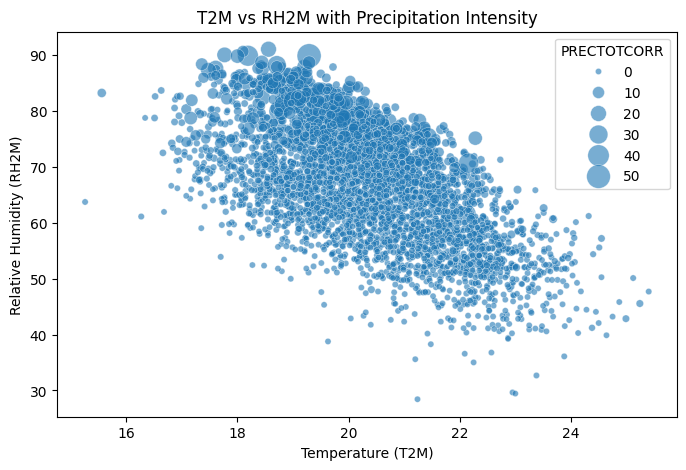

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 300),
    alpha=0.6,
    legend=True
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M with Precipitation Intensity")
plt.show()

**Observation**

- There is a clear negative relationship between temperature and humidity and Moderate temperature range (~18°C to 22°C), Higher humidity zones (~60%–85%)
Precipitation is influenced by a combination of moderate temperature and high humidity, rather than extreme values of either variable.